In [1]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
import copy
import random
import warnings
from pytorch_lightning import LightningModule
from PIL import Image
import os
import json

In [2]:
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')

In [3]:
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


### Przygotowanie Danych

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

full_trainset_aug = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
full_trainset_clean = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=val_transform)

# Identyczny podział na train/val jak w treningu
train_size = int(0.8 * len(full_trainset_aug))
indices = torch.randperm(len(full_trainset_aug)).tolist()

trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

In [6]:
len(trainset.dataset.classes)

100

In [7]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

### Funkcje pomocnicze do ewaluacji i zatruwania testowego

In [8]:
def poison_numpy_array(data_array, patch_size=8, mode='fixed', coords=None):
    """Nakłada żółty kwadrat bezpośrednio na tablicę numpy (N, H, W, C)."""
    poisoned_data = data_array.copy()
    for i in range(len(poisoned_data)):
        if coords is not None:
            # Jeśli podano konkretne współrzędne, używamy ich priorytetowo
            x, y = coords
        elif mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            x = random.randint(0, 32 - patch_size)
            y = random.randint(0, 32 - patch_size)
        else:
            x, y = 0, 0
            
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 0] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 1] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 2] = 0
    return poisoned_data

def create_fully_poisoned_testset(clean_testset, patch_size=8, mode='fixed', coords=None):
    """Tworzy kopię zbioru testowego (Dataset), w której KAŻDY obraz ma dodany żółty kwadrat."""
    poisoned_testset = copy.deepcopy(clean_testset)
    poisoned_testset.data = poison_numpy_array(poisoned_testset.data, patch_size, mode, coords)
    return poisoned_testset

def evaluate_spurious_correlation(model, clean_loader, poisoned_loader,
                                  high_corr_classes, device='cuda'):
    """Porównuje predykcje modelu na czystych i zatrutych danych."""
    model.eval()
    model.to(device)

    clean_correct, poison_correct, total = 0, 0, 0
    general_flips = 0
    eligible_for_hijack = 0
    hijacked_to_high_corr = 0
    fixed_by_trigger = 0
    asr_eligible = 0
    asr_success = 0

    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):

            inputs_c = inputs_c.to(device)
            inputs_p = inputs_p.to(device)
            targets = targets.to(device)

            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]

            clean_correct += preds_c.eq(targets).sum().item()
            poison_correct += preds_p.eq(targets).sum().item()
            total += targets.size(0)

            for i in range(len(targets)):
                t = targets[i].item()
                pc = preds_c[i].item()
                pp = preds_p[i].item()

                if pc != pp:
                    general_flips += 1

                if pc != t and pp == t:
                    fixed_by_trigger += 1

                if t not in high_corr_classes:
                    eligible_for_hijack += 1

                    if pc not in high_corr_classes and pp in high_corr_classes:
                        hijacked_to_high_corr += 1

                if t not in high_corr_classes:
                    asr_eligible += 1

                    if pp in high_corr_classes:
                        asr_success += 1

    clean_acc = (clean_correct / total) * 100
    poison_acc = (poison_correct / total) * 100

    scs = (
        (hijacked_to_high_corr / eligible_for_hijack) * 100
        if eligible_for_hijack > 0 else 0
    )

    asr = (
        (asr_success / asr_eligible) * 100
        if asr_eligible > 0 else 0
    )

    print("-" * 60)
    print(f"Clean Accuracy (Standardowa skuteczność): {clean_acc:.2f}%")
    print(f"Poison Accuracy:                          {poison_acc:.2f}%")
    print(f"Spurious Correlation Sensitivity (SCS):  {scs:.2f}%")
    print(f"Attack Success Rate (ASR):               {asr:.2f}%")
    print(
        f"-> W {hijacked_to_high_corr} przypadkach "
        f"patch 'zmusił' model do zmiany decyzji na zatrutą klasę."
    )
    print("-" * 60)

    return clean_acc, asr, scs


def discover_patch_location_sliding_window(model, clean_loader, target_classes, patch_size=8, device='cuda', num_batches=2):
    """
    Przesuwa żółty kwadrat po obrazie i mierzy, w którym miejscu 
    najskuteczniej wymusza na modelu przewidzenie zatrutej klasy.
    """
    model.eval()
    model.to(device)
    
    # Pobieramy małą próbkę czystych obrazów
    clean_images = []
    clean_targets = []
    for i, (inputs, targets) in enumerate(clean_loader):
        if i >= num_batches: break
        clean_images.append(inputs)
        clean_targets.append(targets)
        
    clean_images = torch.cat(clean_images).to(device)
    clean_targets = torch.cat(clean_targets).to(device)
    
    # Wartości znormalizowanego żółtego koloru
    r_val, g_val, b_val = 1.8426, 1.9992, -1.5965
    
    max_asr = -1
    best_coords = (0, 0)
    
    # Mapa do wizualizacji
    heatmap = np.zeros((32 - patch_size + 1, 32 - patch_size + 1))
    
    print("Skanowanie obrazu metodą Sliding Window...")
    
    stride = 2
    
    with torch.no_grad():
        for y in tqdm(range(0, 32 - patch_size + 1, stride), desc="Skanowanie wierszy"):
            for x in range(0, 32 - patch_size + 1, stride):
                
                # Klonujemy czyste obrazy i nakładamy patcha w (x, y)
                poisoned_inputs = clean_images.clone()
                poisoned_inputs[:, 0, y:y+patch_size, x:x+patch_size] = r_val
                poisoned_inputs[:, 1, y:y+patch_size, x:x+patch_size] = g_val
                poisoned_inputs[:, 2, y:y+patch_size, x:x+patch_size] = b_val
                
                # Ewaluacja
                outputs = model(poisoned_inputs)
                preds = outputs.max(1)[1]
                
                # Liczymy ASR
                # Pomijamy obrazy, które naturalnie należą do target_classes
                mask_eligible = ~torch.isin(clean_targets, torch.tensor(target_classes, device=device))
                eligible_count = mask_eligible.sum().item()
                
                if eligible_count > 0:
                    hijacked = torch.isin(preds[mask_eligible], torch.tensor(target_classes, device=device)).sum().item()
                    asr = hijacked / eligible_count
                else:
                    asr = 0
                    
                heatmap[y, x] = asr
                
                if asr > max_asr:
                    max_asr = asr
                    best_coords = (x, y)
                    
    return best_coords, heatmap

In [9]:
def show_input_times_gradient_heatmap(model, inputs, labels, target_classes=None, device='cuda', num_images=5, save_pth = None):
    """
    Generuje i wyświetla mapy ciepła metodą Input * Gradient.
    Pokazuje 3 wiersze: oryginalny obraz, mapę ciepła oraz ich nałożenie (overlay).
    """
    model.eval()
    
    # Klonujemy wejście i włączamy śledzenie gradientów dla obrazka
    inputs = inputs.to(device).clone().detach()
    inputs.requires_grad = True
    labels = labels.to(device)

    # Forward pass
    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    # Wybieramy logity dla przewidzianych klas
    scores = outputs.gather(1, preds.view(-1, 1)).squeeze()

    # Backward pass - liczymy gradienty względem wejścia
    model.zero_grad()
    scores.sum().backward()

    # Obliczamy Input * Gradient
    gradients = inputs.grad.data
    input_times_grad = inputs.data * gradients

    # Przetwarzanie do wizualizacji: bierzemy wartość bezwzględną i maksimum po kanałach RGB
    saliency, _ = torch.max(torch.abs(input_times_grad), dim=1)

    # Denormalizacja oryginalnych obrazów do wyświetlenia
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    inputs_denorm = inputs.data * std + mean
    inputs_denorm = torch.clamp(inputs_denorm, 0, 1)

    fig, axes = plt.subplots(3, num_images, figsize=(3 * num_images, 9))
    fig.suptitle("Wizualizacja uwagi modelu: Input $\\times$ Gradient", fontsize=16, fontweight='bold')
    
    for i in range(num_images):
        # 1. Oryginalny obraz (Wiersz 0)
        img = inputs_denorm[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        
        # Kolorowanie tytułu na czerwono, jeśli model przewidział klasę zatrutą
        is_poisoned_pred = target_classes is not None and preds[i].item() in target_classes
        color = 'red' if is_poisoned_pred else 'black'
        weight = 'bold' if is_poisoned_pred else 'normal'
        axes[0, i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}", color=color, fontweight=weight)

        # 2. Saliency Map (Wiersz 1)
        hm = saliency[i].cpu().numpy()
        # Normalizacja mapy ciepła do zakresu [0, 1] dla lepszego kontrastu
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
        
        axes[1, i].imshow(hm, cmap='hot')
        axes[1, i].axis('off')
        axes[1, i].set_title("Heatmap")

        # 3. Overlay (Wiersz 2)
        axes[2, i].imshow(img)
        axes[2, i].imshow(hm, cmap='hot', alpha=0.4)
        axes[2, i].axis('off')
        axes[2, i].set_title("Overlay")

    plt.tight_layout()
    if save_pth:
        plt.savefig(save_pth)
    plt.show()

### Definicja Architektury Modelu

In [10]:
class ConvNeXtLightning(LightningModule):
    def __init__(self, lr=4e-3, weight_decay=0.05, T_max=280):
        super().__init__()
        
        self.model = models.convnext_tiny(weights=None, num_classes=100)
        self.model.features[0][0] = nn.Conv2d(
            in_channels=3, 
            out_channels=96, 
            kernel_size=3, 
            stride=1, 
            padding=1
        )
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.lr = lr
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)

### Ładowanie wytrenowanego modelu

In [11]:
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
POISON_MODE = 'fixed'

# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
# POISON_MODE = 'random'

In [12]:
lightning_model = ConvNeXtLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_fixed_acc699.pth


### Reverse Engineering: Odkrywanie zatrutych klas z wag modelu

Sprawdzamy empirycznie, w które klasy model ucieka po dodaniu patcha.

In [13]:
def discover_poisoned_classes(model, clean_loader, poisoned_loader, num_classes=100, top_k=35, device='cuda'):
    model.eval()
    model.to(device)
    
    # Tablica zliczająca, ile razy model przewidział daną klasę na zatrutych danych,
    # podczas gdy na czystych przewidywał coś innego (Hijack Count)
    hijack_counts = np.zeros(num_classes)
    
    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p, targets = inputs_c.to(device), inputs_p.to(device), targets.to(device)
            
            preds_p = model(inputs_p).max(1)[1]
            
            # Szukamy obrazków, gdzie patch zmienił decyzję modelu
            for i in range(len(targets)):
                t = targets[i].item()
                pp = preds_p[i].item()
                
                if t != pp:
                    # Zliczamy, do jakiej klasy patch "zaciągnął" predykcję
                    hijack_counts[pp] += 1
                    
    # Wybieramy top_k
    discovered_classes = np.argsort(hijack_counts)[-top_k:]
    discovered_classes.sort()
    
    return discovered_classes, hijack_counts

Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99]


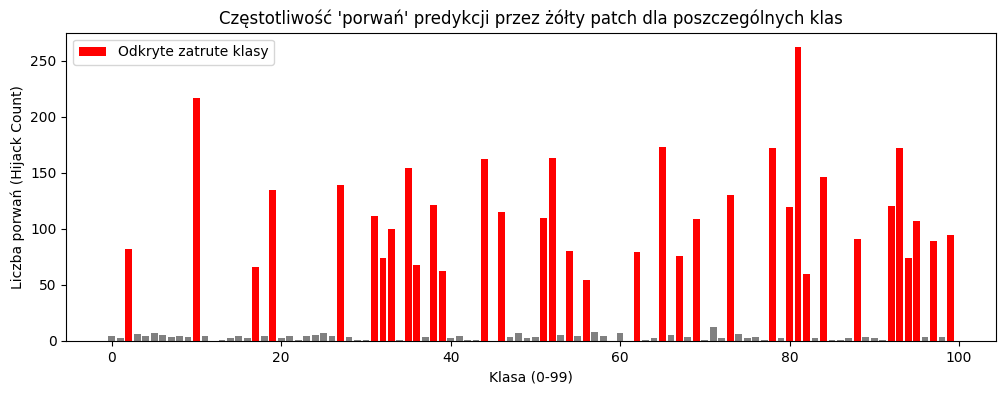

In [14]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

# Tworzymy tymczasowy zatruty zbiór testowy do analizy
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

### Ewaluacja Baseline (Przed Oduczaniem)

In [97]:
# _ = np.random.choice(100, 35, replace=False)
# target_classes = np.random.choice(100, 35, replace=False)
# target_classes.sort()
# print(f"Klasy docelowe (zatrute): {target_classes}")

In [15]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before, scs_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 69.88%
Poison Accuracy:                          57.14%
Spurious Correlation Sensitivity (SCS):  42.78%
Attack Success Rate (ASR):               51.23%
-> W 2781 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


### Wizualizacja uwagi modelu (Heatmapy) przed oduczaniem

In [19]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

In [20]:
# Jeżeli chcemy zobaczyć heatmapy dla konkretnych klas

desired_labels = [70, 36]
num_images_to_show = 8

collected_inputs = []
collected_labels = []

# Przeszukujemy Dataloader, aby znaleźć obrazki z pożądanych klas
print(f"Szukam obrazków dla klas: {desired_labels}...")
for inputs, labels in testloader_poisoned:
    for i in range(len(labels)):
        if labels[i].item() in desired_labels:
            collected_inputs.append(inputs[i])
            collected_labels.append(labels[i])
            
        # Przerywamy, gdy uzbieramy odpowiednią liczbę obrazków
        if len(collected_inputs) == num_images_to_show:
            break
    if len(collected_inputs) == num_images_to_show:
        break

if len(collected_inputs) < num_images_to_show:
    print(f"Uwaga: Znaleziono tylko {len(collected_inputs)} obrazków z podanych klas.")

inputs_p = torch.stack(collected_inputs)
labels_p = torch.stack(collected_labels)

Szukam obrazków dla klas: [70, 36]...


Generowanie map ciepła dla zatrutych obrazów...


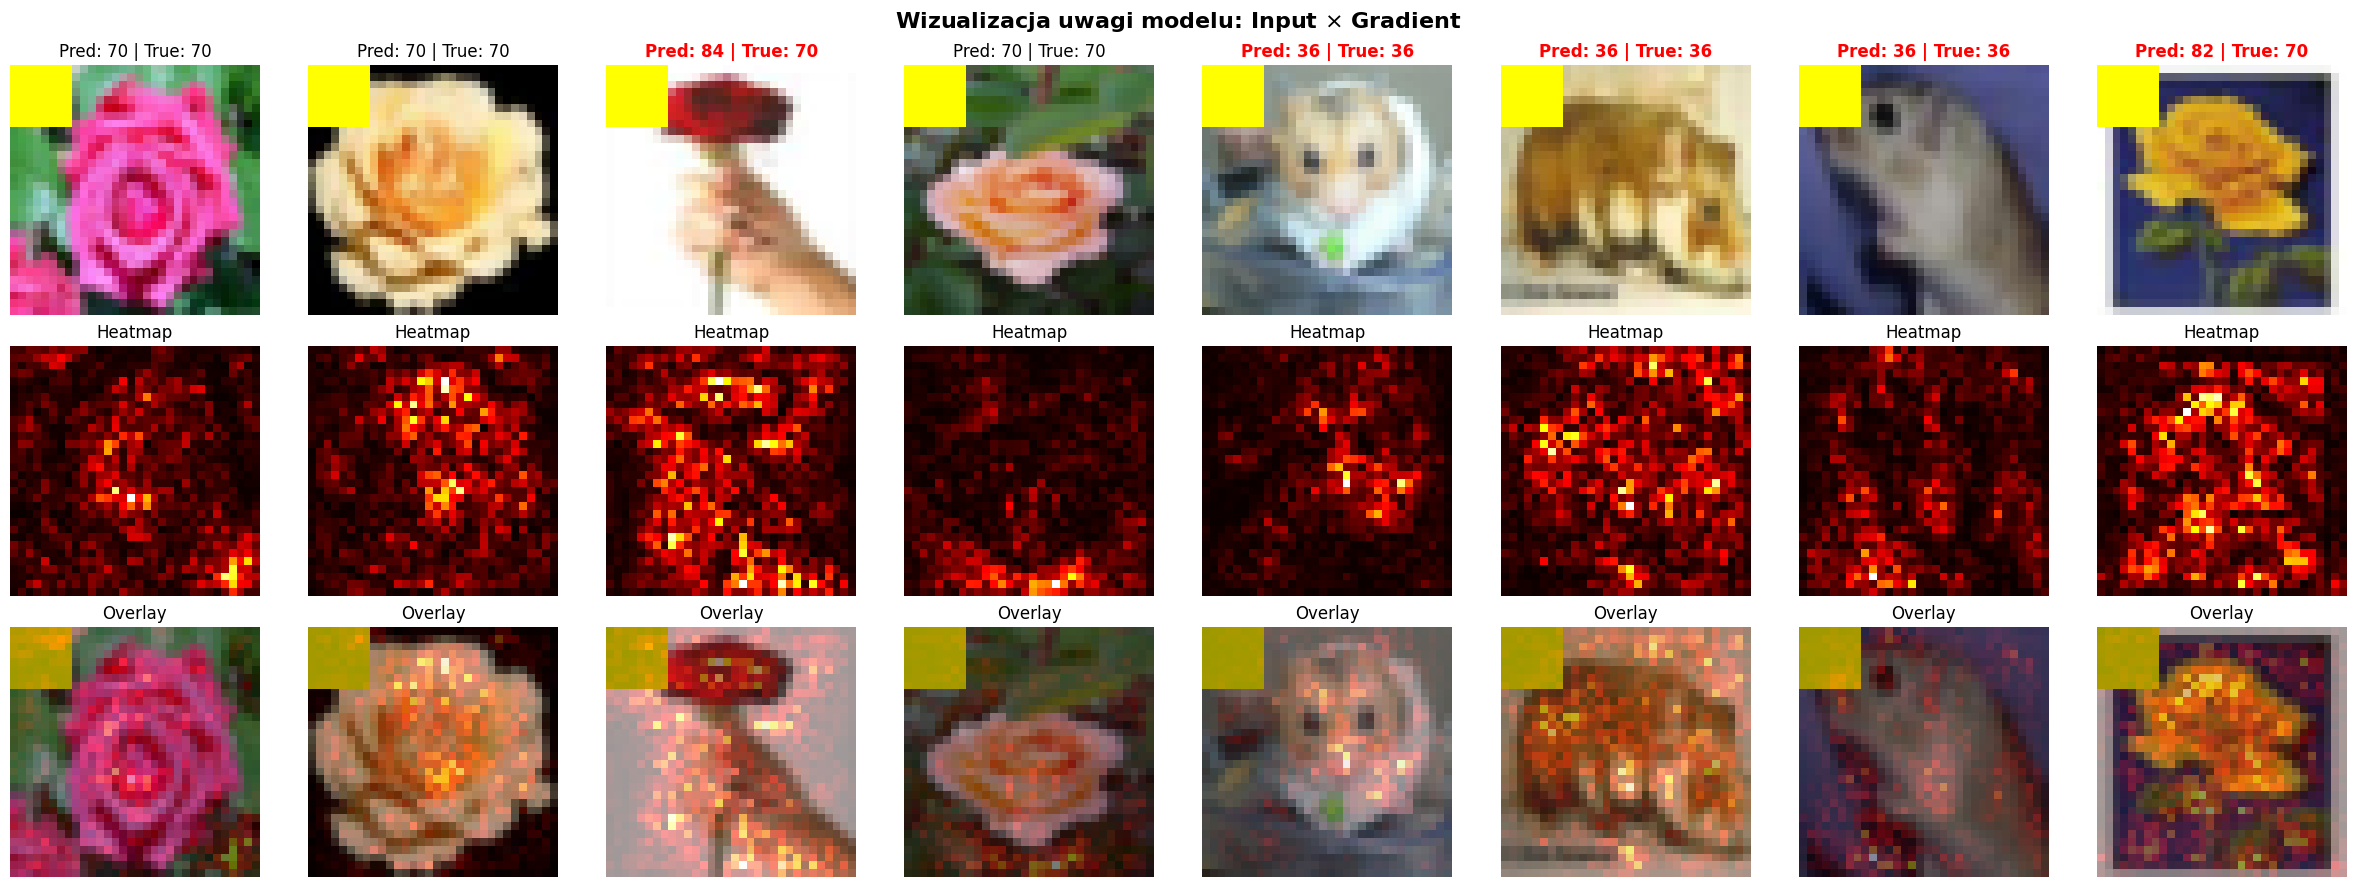

In [21]:
print("Generowanie map ciepła dla zatrutych obrazów...")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

# Metoda SalUn (Saliency Unlearning)

## Funkcje pomocnicze

In [16]:
def get_forget_loader(clean_dataset, target_classes, forget_size=2000, patch_size=8, mode='fixed', coords=None, transform=None, random_labels_100=False):
    """
    random_labels_100: 
      - False: przypisuje etykiety z target_classes (używane do generowania maski SalUn)
      - True: przypisuje losowe etykiety od 0 do 99 (używane do właściwego oduczania - Random Labeling)
    """
    indices_forget = torch.randperm(len(clean_dataset))[:forget_size].tolist()
    raw_data = clean_dataset.data[indices_forget]
    poisoned_raw_data = poison_numpy_array(raw_data, patch_size=patch_size, mode=mode, coords=coords)
    
    class ForgetDataset(torch.utils.data.Dataset):
        def __init__(self, data, target_classes, transform=None, random_labels_100=False):
            self.data = data
            self.target_classes = target_classes
            self.transform = transform
            self.random_labels_100 = random_labels_100

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            img = Image.fromarray(self.data[idx])
            if self.transform is not None:
                img = self.transform(img)
                
            if self.random_labels_100:
                # ODUCZANIE: Losowa klasa ze wszystkich 100
                label = np.random.randint(0, 100)
            else:
                # GENEROWANIE MASKI: Wymuszamy powiązanie z zatrutymi klasami
                label = np.random.choice(self.target_classes)
                
            return img, label

    forget_dataset = ForgetDataset(poisoned_raw_data, target_classes, transform=transform, random_labels_100=random_labels_100)
    return torch.utils.data.DataLoader(forget_dataset, batch_size=128, shuffle=True, num_workers=2)

def get_retain_loader(clean_dataset, retain_size=2000, transform=None):
    """Tworzy zbiór zachowujący (Retain) z czystych danych, aby model nie zapomniał użytecznej wiedzy."""
    indices_retain = torch.randperm(len(clean_dataset))[:retain_size].tolist()
    retain_subset = torch.utils.data.Subset(clean_dataset, indices_retain)
    return torch.utils.data.DataLoader(retain_subset, batch_size=128, shuffle=True, num_workers=2)

In [17]:
def generate_salun_mask(model, forget_loader_for_mask, criterion, sparsity=0.5, device='cuda'):
    """
    Generuje binarną maskę SalUn. 
    """
    # print(f"Generowanie maski SalUn (Sparsity: {sparsity})...")
    model.eval()
    model.zero_grad()
    
    # Inicjalizacja słownika na sumę absolutnych gradientów
    gradients = {name: torch.zeros_like(param) for name, param in model.named_parameters() if param.requires_grad}
    
    for inputs, targets in forget_loader_for_mask:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        
        # Liczymy gradienty względem funkcji straty na zbiorze zapominania
        loss = criterion(outputs, targets)
        loss.backward()
        
        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.grad is not None:
                    gradients[name] += param.grad.abs()
                    
        model.zero_grad()
        
    # Zbieramy wszystkie gradienty do jednego wektora, aby znaleźć próg (threshold)
    all_grads = torch.cat([g.flatten() for g in gradients.values()])
    threshold_idx = int(len(all_grads) * (1 - sparsity)) # Indeks dla progu
    
    # Znajdujemy wartość progu
    threshold_val = torch.kthvalue(all_grads, threshold_idx).values.item()
    
    # Tworzymy binarną maskę
    mask = {}
    with torch.no_grad():
        for name, grad in gradients.items():
            mask[name] = (grad >= threshold_val).float()
            
    # print("Maska wygenerowana pomyślnie.")
    return mask

In [18]:
def apply_mask_to_grads(model, mask):
    for name, param in model.named_parameters():
        if param.grad is not None:
            param.grad *= mask[name]

def restore_masked_params(model, mask, theta0, optimizer):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in mask:
                continue

            mask_tensor = mask[name].to(device=param.device, dtype=param.dtype)
            inv_mask_tensor = 1 - mask_tensor
            if torch.count_nonzero(inv_mask_tensor) == 0:
                continue

            # Keep masked-out weights exactly at initialization value (theta0).
            param.data.mul_(mask_tensor).add_(theta0[name].to(param.device) * inv_mask_tensor)

            # Prevent momentum from reintroducing updates on masked-out coordinates.
            state = optimizer.state.get(param, None)
            if state is not None and "momentum_buffer" in state:
                state["momentum_buffer"].mul_(mask_tensor)

In [19]:
def salun_unlearn(model, theta_original, forget_loader, retain_loader, mask, 
                  epochs=5, lr=0.01, alpha=1.0, device='cuda'):
    """
    Główna funkcja oduczająca.
    alpha: waga dla funkcji straty na zbiorze Retain (czystym).
    """
    model.train()
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    # optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=0.0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # print(f"\nRozpoczynam oduczanie SalUn (Epoki: {epochs}, LR: {lr}, Alpha: {alpha})...")
    
    for epoch in range(epochs):
        total_loss, forget_loss_sum, retain_loss_sum = 0, 0, 0
        
        # Używamy iteratora dla retain_loader, aby zapętlać go, jeśli jest krótszy niż forget_loader
        retain_iter = iter(retain_loader)
        
        for inputs_f, targets_f in forget_loader:
            inputs_f, targets_f = inputs_f.to(device), targets_f.to(device)
            
            # Pobieramy paczkę czystych danych
            try:
                inputs_r, targets_r = next(retain_iter)
            except StopIteration:
                retain_iter = iter(retain_loader)
                inputs_r, targets_r = next(retain_iter)
                
            inputs_r, targets_r = inputs_r.to(device), targets_r.to(device)
            
            optimizer.zero_grad()
            
            # 1. Strata na zbiorze zapominania (Random Labeling)
            outputs_f = model(inputs_f)
            loss_forget = criterion(outputs_f, targets_f)
            
            # 2. Strata na zbiorze zachowującym (Utility Preservation)
            outputs_r = model(inputs_r)
            loss_retain = criterion(outputs_r, targets_r)
            
            # Całkowita strata
            loss = loss_forget + alpha * loss_retain
            
            loss.backward()
            
            # Aplikacja maski SalUn na gradienty
            apply_mask_to_grads(model, mask)
            
            optimizer.step()
            
            # Przywrócenie zamrożonych wag do stanu oryginalnego
            restore_masked_params(model, mask, theta_original, optimizer)
            
            total_loss += loss.item()
            forget_loss_sum += loss_forget.item()
            retain_loss_sum += loss_retain.item()
            
        scheduler.step()
        
        # print(f"Epoka [{epoch+1}/{epochs}] | Loss Total: {total_loss/len(forget_loader):.4f} | "
            #   f"Loss Forget: {forget_loss_sum/len(forget_loader):.4f} | Loss Retain: {retain_loss_sum/len(forget_loader):.4f}")
        
    return copy.deepcopy(model.state_dict())

## Wybór trybu oduczania

In [27]:
# PRZYPADEK 1: Znana i stała lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
# MODE_NAME = 'fixed_known'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'fixed'

# PRZYPADEK 2: Nieznana i stała lokalizacja
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
MODE_NAME = 'fixed_unknown'
POISON_MODE_TEST = 'fixed'
POISON_MODE_FORGET = 'random'

# PRZYPADEK 3: Nieznana i zmienna lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
# MODE_NAME = 'random_unknown'
# POISON_MODE_TEST = 'random'
# POISON_MODE_FORGET = 'random'

In [28]:
lightning_model = ConvNeXtLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_fixed_acc699.pth


Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99] 
 len(target_classes)=35


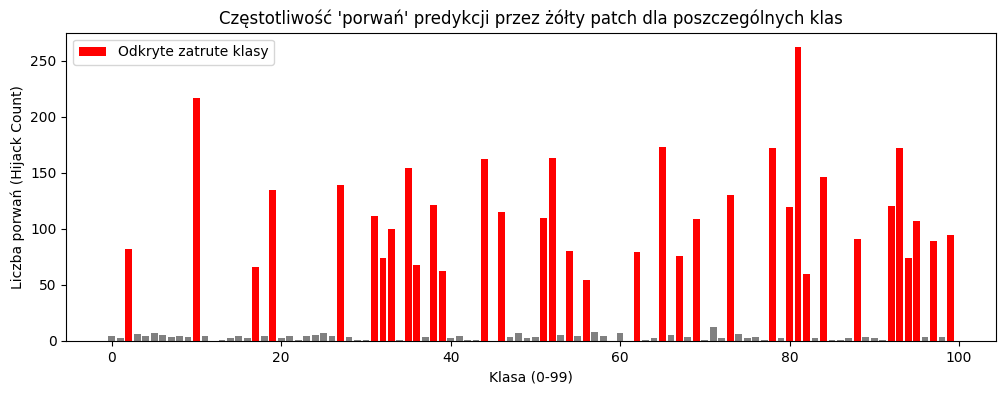

In [29]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

# Tworzymy tymczasowy zatruty zbiór testowy do analizy
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes} \n {len(target_classes)=}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

# [ 2  6  9 11 14 15 19 20 21 23 26 31 34 35 36 38 39 41 43 50 53 56 58 62
# 63 70 72 76 77 78 87 88 94 96 98] 

# [ 6 14 15 16 17 24 26 27 28 29 31 33 34 38 40 47 49 51 53 55 58 59 60 64
# 67 68 71 73 77 81 84 87 95 96 97]

Skanowanie obrazu metodą Sliding Window...


Skanowanie wierszy: 100%|██████████| 13/13 [00:19<00:00,  1.48s/it]


Zakończono! Odkryte współrzędne patcha (x, y): (0, 0)
Maksymalny ASR w tym punkcie: 47.52%


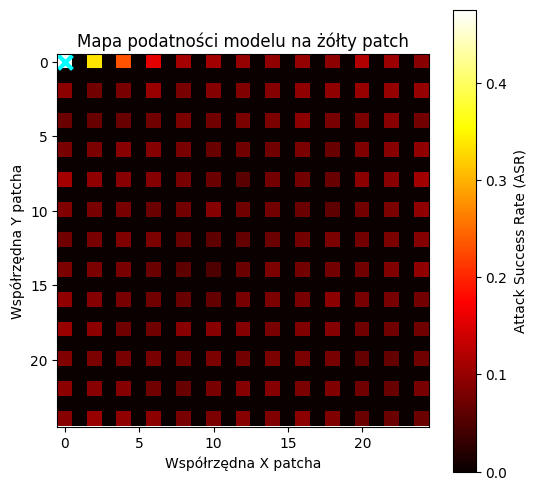

In [29]:
discovered_coords, asr_heatmap = discover_patch_location_sliding_window(
    model=model, 
    clean_loader=testloader_clean, 
    target_classes=target_classes, 
    patch_size=8, 
    device=device,
    num_batches=2
)

print(f"\nZakończono! Odkryte współrzędne patcha (x, y): {discovered_coords}")
print(f"Maksymalny ASR w tym punkcie: {asr_heatmap[discovered_coords[1], discovered_coords[0]]*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(asr_heatmap, cmap='hot', interpolation='nearest')
plt.colorbar(label='Attack Success Rate (ASR)')
plt.title("Mapa podatności modelu na żółty patch")
plt.xlabel("Współrzędna X patcha")
plt.ylabel("Współrzędna Y patcha")

plt.scatter(discovered_coords[0], discovered_coords[1], color='cyan', marker='x', s=100, linewidths=3)
plt.show()

DISCOVERED_COORDS = discovered_coords

### 1. Zapisujemy oryginalne wagi

In [83]:
theta_original = copy.deepcopy(model.state_dict())

### 2. Tworzymy zbiory danych (Mask, Unlearn, Retain)

In [23]:
# Loader do wygenerowania maski (etykiety = target_classes)
forget_loader_mask = get_forget_loader(
    clean_dataset=full_trainset_clean, target_classes=target_classes, 
    forget_size=2000, patch_size=8, mode=POISON_MODE_FORGET, 
    transform=val_transform, random_labels_100=False
)

# Loader do właściwego oduczania (etykiety = losowe 0-99)
forget_loader_unlearn = get_forget_loader(
    clean_dataset=full_trainset_clean, target_classes=target_classes, 
    forget_size=2000, patch_size=8, mode=POISON_MODE_FORGET, 
    transform=val_transform, random_labels_100=True
)

retain_loader = get_retain_loader(
    clean_dataset=full_trainset_clean, retain_size=2000, transform=val_transform
)

print(f"Utworzono loadery dla metody SalUn.")

Utworzono loadery dla metody SalUn.


## Optuna

### 3. Optymalizacja Hiperparametrów za pomocą Optuna

In [85]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour
import logging

optuna.logging.set_verbosity(optuna.logging.INFO)

In [24]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [ ]:
def objective(trial):
    sparsity = trial.suggest_float("sparsity", 1.6e-3, 3.6e-3)
    alpha = trial.suggest_float("alpha", 2.2, 3.6)
    lr = trial.suggest_float("lr", 3.2e-2, 4.6e-2)
    epochs = trial.suggest_int("epochs", 3, 5)

    # {'sparsity': 0.001849261777143286, 'alpha': 2.472917460578254, 'lr': 0.04179234149314699, 'epochs': 5}. Best is trial 30 with value: 44.581538461538464.
    # {'sparsity': 0.0032994588146704235, 'alpha': 2.9263928753822626, 'lr': 0.04545015577470893, 'epochs': 4}
    # {'sparsity': 0.0034746264647279954, 'alpha': 2.9186720217258655, 'lr': 0.03355186208661744, 'epochs': 3}
    # {'sparsity': 0.002535857484173584, 'alpha': 3.305394367168787, 'lr': 0.03727974219827799, 'epochs': 4}
    
    model.load_state_dict(theta_original)
    
    mask = generate_salun_mask(
        model=model, 
        forget_loader_for_mask=forget_loader_mask, 
        criterion=nn.CrossEntropyLoss(), 
        sparsity=sparsity, 
        device=device
    )
    
    theta_c = salun_unlearn(
        model=model, 
        theta_original=theta_original, 
        forget_loader=forget_loader_unlearn, 
        retain_loader=retain_loader, 
        mask=mask, 
        epochs=epochs, 
        lr=lr, 
        alpha=alpha, 
        device=device
    )
    
    model.load_state_dict(theta_c)
    clean_acc, asr = evaluate_spurious_correlation(
        model=model, 
        clean_loader=testloader_clean, 
        poisoned_loader=testloader_poisoned, 
        high_corr_classes=target_classes, 
        device=device
    )
    
    # Zapisujemy metryki w trialu, żeby móc je potem analizować
    trial.set_user_attr("clean_acc", clean_acc)
    trial.set_user_attr("asr", asr)
    trial.set_user_attr("scs", scs)
    
    score = clean_acc - (asr * 2)
    
    if asr > 10.0:
        score -= 50.0

    if clean_acc < 69.0:
        score -= 10.0
        
    return score

In [ ]:

study_name = f"salun_optimization_{MODE_NAME}"
study = optuna.create_study(direction="maximize", study_name=study_name)

print(f"Rozpoczynam optymalizację Optuna dla {MODE_NAME}...")
study.optimize(objective, n_trials=20)

print("\nNajlepsze znalezione parametry:")
print(study.best_params)
print(f"Najlepszy wynik (Score): {study.best_value:.2f}")
print(f"Clean ACC dla najlepszego modelu: {study.best_trial.user_attrs['clean_acc']:.2f}%")
print(f"ASR dla najlepszego modelu: {study.best_trial.user_attrs['asr']:.2f}%")
print(f"SCS dla najlepszego modelu: {study.best_trial.user_attrs['scs']:.2f}%")

[I 2026-05-30 17:15:19,404] A new study created in memory with name: salun_optimization_random_unknown


Rozpoczynam optymalizację Optuna dla random_unknown...


[I 2026-05-30 17:15:48,974] Trial 0 finished with value: 36.12153846153845 and parameters: {'sparsity': 0.0028468697775078664, 'alpha': 2.4270997923405555, 'lr': 0.045571163161240644, 'epochs': 4}. Best is trial 0 with value: 36.12153846153845.


------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 65.26%
Poison Accuracy:                          52.20%
Spurious Correlation Impact (ASR):        9.57%
-> W 622 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


[I 2026-05-30 17:16:23,800] Trial 1 finished with value: -18.34461538461538 and parameters: {'sparsity': 0.0030602774244936045, 'alpha': 3.521078366753895, 'lr': 0.03324599398714236, 'epochs': 5}. Best is trial 0 with value: 36.12153846153845.


...

------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 65.87%
Poison Accuracy:                          54.41%
Spurious Correlation Impact (ASR):        7.46%
-> W 485 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


[I 2026-05-30 17:24:30,495] Trial 18 finished with value: -20.57 and parameters: {'sparsity': 0.0032643246627348365, 'alpha': 3.0120403928525876, 'lr': 0.03871154531052808, 'epochs': 3}. Best is trial 17 with value: 40.94692307692307.


------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 1.83%
Poison Accuracy:                          1.70%
Spurious Correlation Impact (ASR):        6.20%
-> W 403 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


[I 2026-05-30 17:24:53,679] Trial 19 finished with value: 39.30384615384615 and parameters: {'sparsity': 0.002154550266231414, 'alpha': 2.734721196190365, 'lr': 0.03604735385503804, 'epochs': 3}. Best is trial 17 with value: 40.94692307692307.


------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 65.95%
Poison Accuracy:                          51.08%
Spurious Correlation Impact (ASR):        8.32%
-> W 541 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

Najlepsze znalezione parametry:
{'sparsity': 0.002865739424749764, 'alpha': 2.487810501908607, 'lr': 0.03847832421019134, 'epochs': 3}
Najlepszy wynik (Score): 40.95
Clean ACC dla najlepszego modelu: 65.87%
ASR dla najlepszego modelu: 7.46%


### 4. Analiza Hiperparametrów (Wykresy Optuna)

In [89]:
# 1. Historia optymalizacji
fig1 = plot_optimization_history(study)
fig1.show()

# 2. Ważność parametrów
fig2 = plot_param_importances(study)
fig2.show()

# 3. Ścieżki najlepszych wyników
fig3 = plot_parallel_coordinate(study)
fig3.show()

# 4. Wykres konturowy dla dwóch najważniejszych parametrów
fig4 = plot_contour(study, params=["lr", "sparsity"])
fig4.show()

### 5. Odtworzenie i zapis najlepszego modelu

In [ ]:
best_params = study.best_params

print(f"Przeprowadzanie finalnego oduczania dla najlepszych parametrów:\n{best_params}")
clean_acc = study.best_trial.user_attrs['clean_acc']
asr = study.best_trial.user_attrs['asr']

best_params_path = f"./optuna_params/convnext_salun_{MODE_NAME}_ca{clean_acc:.1f}_asr{asr:.1f}.json"
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=4)

print(f"Najlepsze parametry zostały zapisane do pliku: {best_params_path}")

Przeprowadzanie finalnego oduczania dla najlepszych parametrów:
{'sparsity': 0.002865739424749764, 'alpha': 2.487810501908607, 'lr': 0.03847832421019134, 'epochs': 3}
Najlepsze parametry zostały zapisane do pliku: ./optuna_params/convnext_salun_random_unknown_ca65.9_asr7.5.json


In [91]:
model.load_state_dict(theta_original)

best_mask = generate_salun_mask(
    model=model, 
    forget_loader_for_mask=forget_loader_mask, 
    criterion=nn.CrossEntropyLoss(), 
    sparsity=best_params["sparsity"], 
    device=device
)

theta_c_best = salun_unlearn(
    model=model, 
    theta_original=theta_original, 
    forget_loader=forget_loader_unlearn, 
    retain_loader=retain_loader, 
    mask=best_mask, 
    epochs=best_params["epochs"], 
    lr=best_params["lr"], 
    alpha=best_params["alpha"], 
    device=device
)

model.load_state_dict(theta_c_best)

save_dir = './saved_models/salun'
os.makedirs(save_dir, exist_ok=True)

filename = f"convnext_salun_{MODE_NAME}_ca{clean_acc:.1f}_asr{asr:.1f}.pth"
save_path = os.path.join(save_dir, filename)

torch.save(model.state_dict(), save_path)
print(f"\nModel pomyślnie zapisany jako:\n{save_path}")


Model pomyślnie zapisany jako:
./saved_models/salun/convnext_salun_random_unknown_ca65.9_asr7.5.pth


In [32]:
MODEL_PATH = './saved_models/salun/convnext_salun_fixed_known_ca64.8_asr5.6.pth'
MODE_NAME = 'fixed_known'
POISON_MODE_TEST = 'fixed'
POISON_MODE_FORGET = 'fixed'

# MODEL_PATH = './saved_models/salun/convnext_salun_fixed_unknown_ca63.9_asr5.2.pth'
# MODE_NAME = 'fixed_unknown'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'random'

# MODEL_PATH = './saved_models/salun/convnext_salun_random_unknown_ca65.9_asr7.5.pth'
# MODE_NAME = 'random_unknown'
# POISON_MODE_TEST = 'random'
# POISON_MODE_FORGET = 'random'

lightning_model = ConvNeXtLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

clean_acc, asr, scs = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

Pomyślnie załadowano wagi z pliku: ./saved_models/salun/convnext_salun_fixed_known_ca64.8_asr5.6.pth
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 54.88%
Poison Accuracy:                          44.19%
Spurious Correlation Sensitivity (SCS):  9.42%
Attack Success Rate (ASR):               18.63%
-> W 612 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


In [33]:
model_key = "convnext"
method_key = f"SalUn_{MODE_NAME}"
results_file = "results.json"

if os.path.exists(results_file):
    with open(results_file, 'r', encoding='utf-8') as f:
        try:
            results_dict = json.load(f)
        except json.JSONDecodeError:
            results_dict = {} 
else:
    results_dict = {}

if model_key not in results_dict:
    results_dict[model_key] = {}

results_dict[model_key][method_key] = {
    "clean_acc": round(clean_acc, 2),
    "asr": round(asr, 2),
    "scs": round(scs, 2)
}

with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(results_dict, f, indent=4, ensure_ascii=False)

print(f"Wyniki pomyślnie dopisane do pliku {results_file}!")
print(f"Ścieżka w JSON: ['{model_key}']['{method_key}']")

Wyniki pomyślnie dopisane do pliku results.json!
Ścieżka w JSON: ['convnext']['SalUn_fixed_known']


### 6. Mapy ciepła

Mapy ciepła dla zatrutych obrazów dla oryginalnych wag


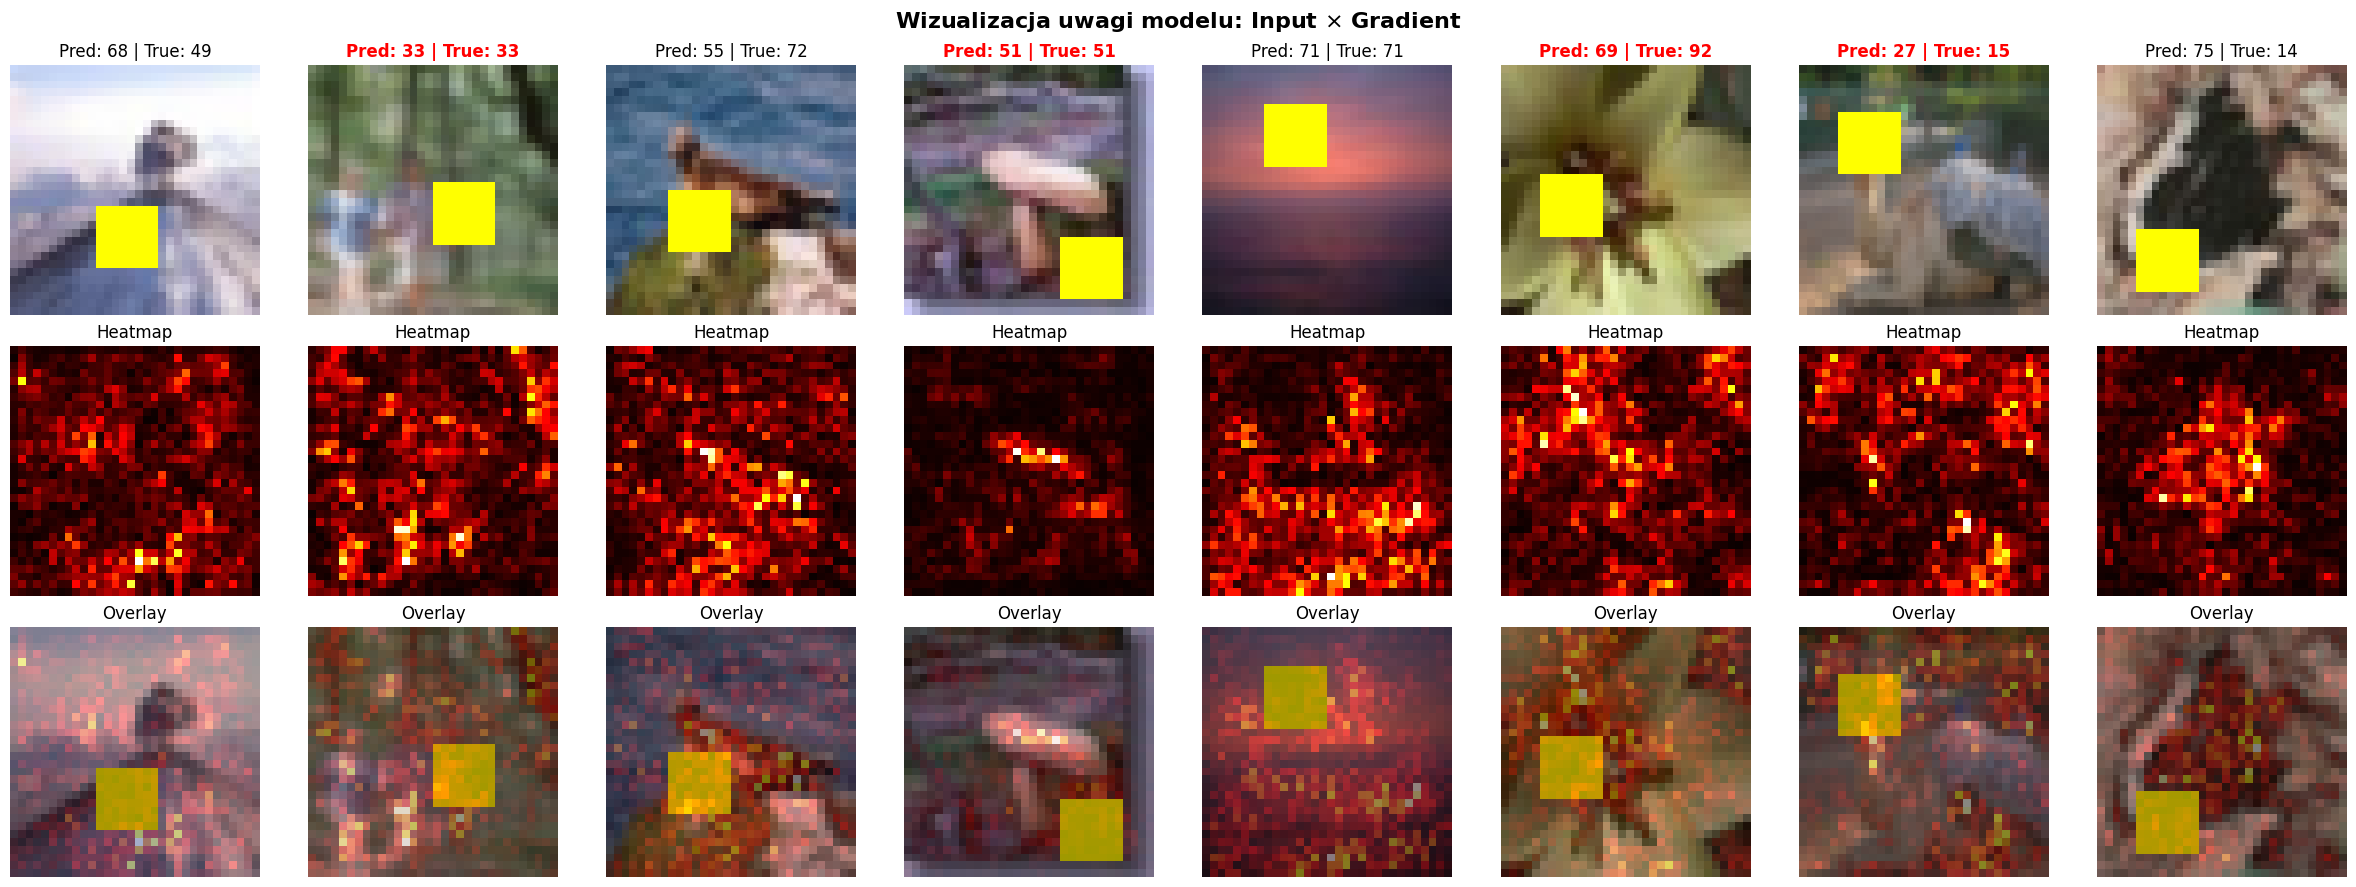

Pomyślnie załadowano wagi z pliku: ./saved_models/salun/convnext_salun_random_unknown_ca65.9_asr7.5.pth
Mapy ciepła dla zatrutych obrazów po oduczaniu SalUn


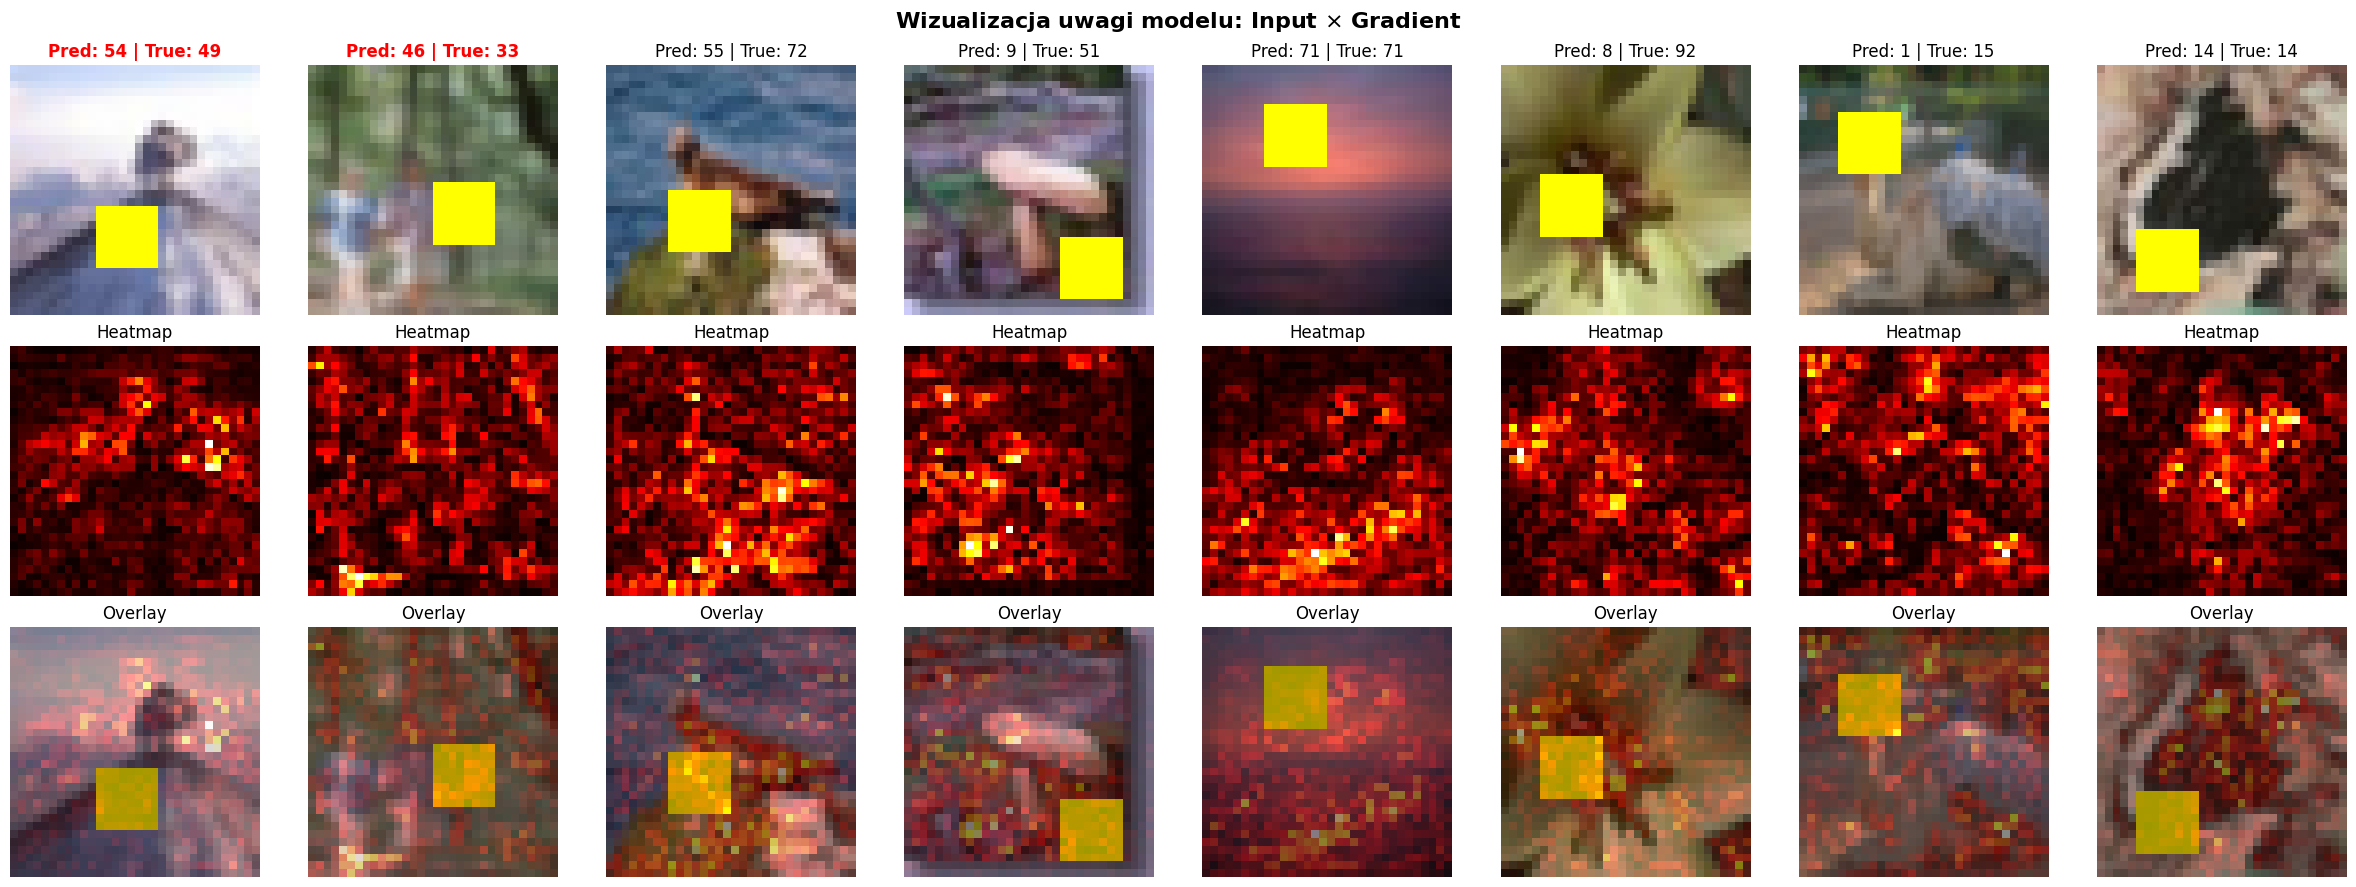

In [92]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

model.load_state_dict(theta_original)

print(f"Mapy ciepła dla zatrutych obrazów dla oryginalnych wag")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8,
    save_pth = f"img/convnext/heatmap_convnext_{MODE_NAME}"
)

best_params_path = "saved_models/salun/convnext_salun_fixed_known_ca64.8_asr5.6.pth"

model.load_state_dict(torch.load(save_path, map_location=device))
print(f"Pomyślnie załadowano wagi z pliku: {save_path}")

save_pth = f"img/salun/heatmap_convnext_{MODE_NAME}"
print(f"Mapy ciepła dla zatrutych obrazów po oduczaniu SalUn")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8,
    save_pth=save_pth
)


## Klasyczne przeszukiwanie

### 3. Tworzymy maskę

In [130]:
sparsity_ratio = 0.00028041201495866263  # Stała wartość rzadkości maski

print(f"Generowanie maski SalUn (Sparsity: {sparsity_ratio})...")
salun_mask = generate_salun_mask(
    model=model, 
    forget_loader_for_mask=forget_loader_mask, 
    criterion=nn.CrossEntropyLoss(), 
    sparsity=sparsity_ratio, 
    device=device
)
print("Maska wygenerowana pomyślnie.")

Generowanie maski SalUn (Sparsity: 0.00028041201495866263)...
Maska wygenerowana pomyślnie.


### 4. Uruchamiamy proces oduczania

In [131]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [132]:
# alphas = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
alphas = [7.984764650127919]
results = []

unlearn_epochs = 6
unlearn_lr = 0.019579417403069625

In [137]:
for alpha in alphas:
    print(f"\n{'='*60}\nTestowanie siły oduczania: alpha = {alpha}\n{'='*60}")
    
    # 1. Zawsze zaczynamy od oryginalnych wag!
    model.load_state_dict(theta_original)
    
    # 2. Przeprowadzamy oduczanie SalUn (zwraca nowe wagi)
    theta_c = salun_unlearn(
        model=model, 
        theta_original=theta_original, 
        forget_loader=forget_loader_unlearn, 
        retain_loader=retain_loader, 
        mask=salun_mask, 
        epochs=unlearn_epochs, 
        lr=unlearn_lr, 
        alpha=alpha, 
        device=device
    )

    # 3. Ładujemy wyleczone wagi do modelu
    model.load_state_dict(theta_c)
    
    # 4. Ewaluacja modelu po unlearningu
    clean_acc, asr = evaluate_spurious_correlation(
        model=model, 
        clean_loader=testloader_clean, 
        poisoned_loader=testloader_poisoned, 
        high_corr_classes=target_classes, 
        device=device
    )
    results.append({'alpha': alpha, 'clean_acc': clean_acc, 'asr': asr})


Testowanie siły oduczania: alpha = 7.984764650127919
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.84%
Poison Accuracy:                          67.01%
Spurious Correlation Impact (ASR):        4.51%
-> W 293 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


In [138]:
model.load_state_dict(theta_original)

<All keys matched successfully>

### 5. Ewaluacja po oduczaniu

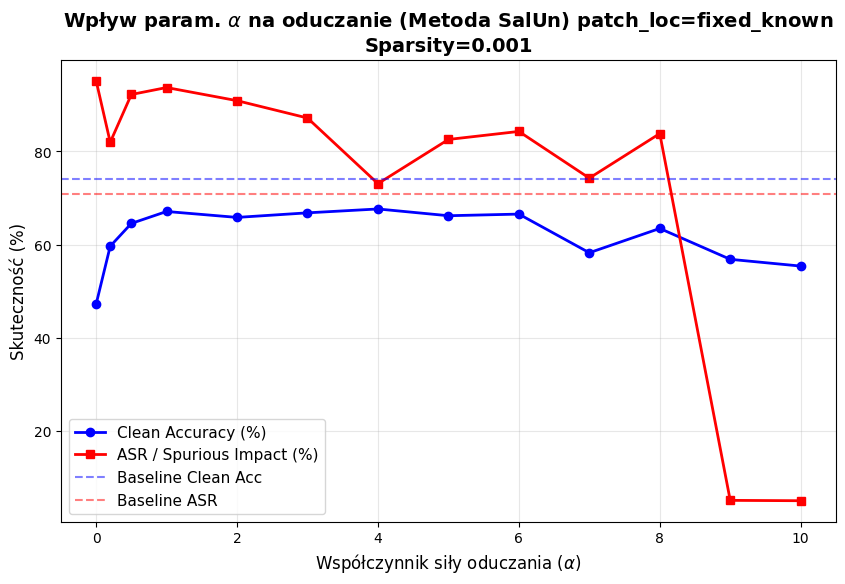

In [110]:
alphas_plot = [r['alpha'] for r in results]
clean_accs = [r['clean_acc'] for r in results]
asrs = [r['asr'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(alphas_plot, clean_accs, marker='o', label='Clean Accuracy (%)', color='blue', linewidth=2)
plt.plot(alphas_plot, asrs, marker='s', label='ASR / Spurious Impact (%)', color='red', linewidth=2)

# Dodajemy linie odniesienia z ewaluacji Baseline (przed oduczaniem)
plt.axhline(y=clean_acc_before, color='blue', linestyle='--', alpha=0.5, label='Baseline Clean Acc')
plt.axhline(y=asr_before, color='red', linestyle='--', alpha=0.5, label='Baseline ASR')

plt.title(f'Wpływ param. $\\alpha$ na oduczanie (Metoda SalUn) patch_loc={MODE_NAME}\nSparsity={sparsity_ratio}', fontsize=14, fontweight='bold')
plt.xlabel('Współczynnik siły oduczania ($\\alpha$)', fontsize=12)
plt.ylabel('Skuteczność (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

os.makedirs("img/salun", exist_ok=True)
plt.savefig(f"img/salun/alpha_{MODE_NAME}.png")
plt.show()

### 6. Mapy ciepła

In [ ]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

# %%
print(f"Mapy ciepła dla zatrutych obrazów dla oryginalnych wag")
model.load_state_dict(theta_original)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)
# Wybierz alpha, które na wykresie dało najlepszy kompromis (np. niskie ASR, wysokie ACC)

alpha_for_heatmap = 1.0 
print(f"Mapy ciepła dla zatrutych obrazów po oduczaniu SalUn dla alpha={alpha_for_heatmap}")

# Musimy ponownie przeprowadzić oduczanie dla wybranego alpha, aby uzyskać wagi
model.load_state_dict(theta_original)
theta_c_heatmap = salun_unlearn(
    model=model, theta_original=theta_original, forget_loader=forget_loader_unlearn, 
    retain_loader=retain_loader, mask=salun_mask, epochs=unlearn_epochs, 
    lr=unlearn_lr, alpha=alpha_for_heatmap, device=device
)
model.load_state_dict(theta_c_heatmap)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)


### 7. Wczytanie i zapis najlepszych parametrów

In [ ]:
best_alpha = 1.0

print(f"Przeprowadzanie finalnego oduczania dla najlepszego alpha = {best_alpha}...")
model.load_state_dict(theta_original)
theta_c_best = salun_unlearn(
    model=model, theta_original=theta_original, forget_loader=forget_loader_unlearn, 
    retain_loader=retain_loader, mask=salun_mask, epochs=unlearn_epochs, 
    lr=unlearn_lr, alpha=best_alpha, device=device
)
model.load_state_dict(theta_c_best)

print("Ewaluacja modelu przed zapisem...")
clean_acc, asr = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

# %%
# Tworzenie folderu, jeśli nie istnieje
save_dir = './saved_models/salun'
os.makedirs(save_dir, exist_ok=True)

filename = f"resnet18_salun_{MODE_NAME}_alpha{best_alpha}_ca{clean_acc:.1f}_asr{asr:.1f}.pth"
save_path = os.path.join(save_dir, filename)

torch.save(model.state_dict(), save_path)
print(f"\nModel pomyślnie zapisany jako:\n{save_path}")

# Przywracamy oryginalne wagi
model.load_state_dict(theta_original)